<a href="https://colab.research.google.com/drive/1LsZuqV42EZpFDvtyFqjl5A5du5jVQBtn" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model For Predicting MNIST Images

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

## Changing To CPU

In [21]:
# however, to be able to save and load the complete model we need to use "cpu"
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


## Data Preparation 

In [22]:
# Define a transformation to flatten the 8x8 images
transform = transforms.Compose([
    transforms.Resize((6,6)),         # Resize the PIL Image to 8x8 first (MNIST images ar
    transforms.ToTensor(),             # Then convert to tensor
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 36
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

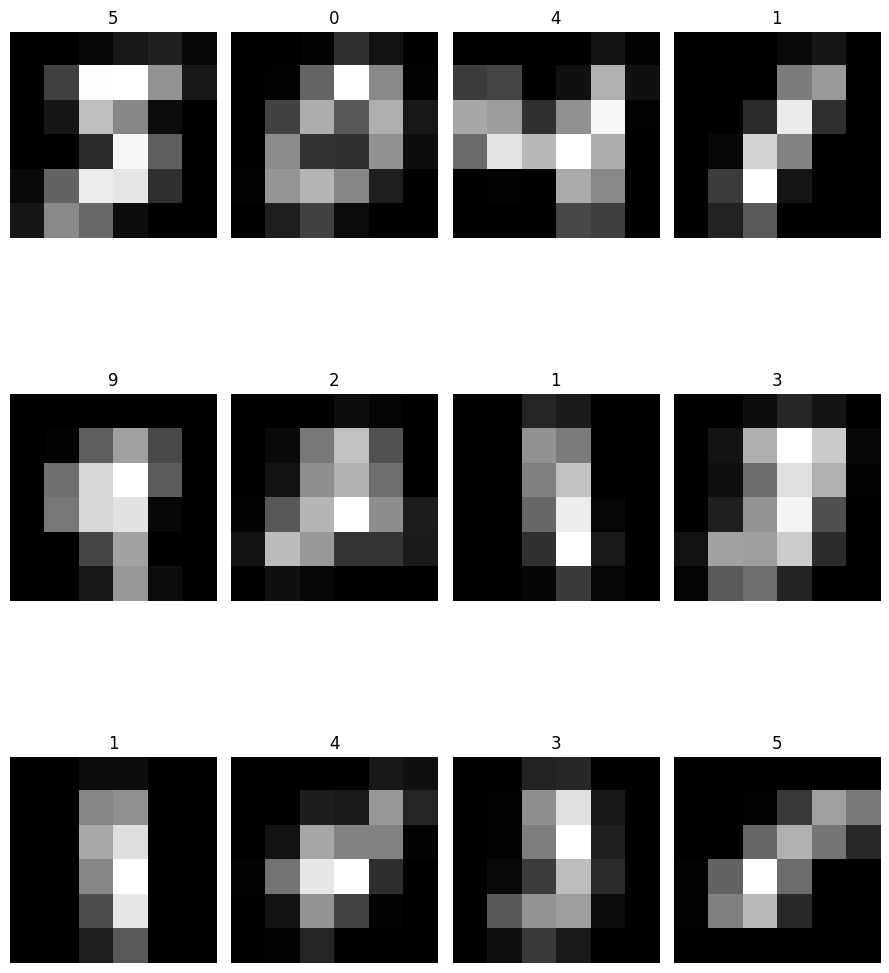

In [23]:
# Visualise data
images, labels = zip(*[train_dataset[i] for i in range(12)])

fig, axes = plt.subplots(3, 4, figsize=(9, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze(0) # Remove the channel dimension (1,) -> (8, 8)
    ax.imshow(img, cmap='gray')
    ax.set_title(str(labels[i]), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Model Development (CNN)

In [24]:
# Convolutional block with batch normalization: ic=input channels; oc=output channels
def conv(ic, oc, act=True):
    ks = 3
    layers = [
        nn.Conv2d(ic, oc, stride=2, kernel_size=ks, padding=ks//2),
        nn.BatchNorm2d(oc)  # insert nn.BatchNorm2d layer after each convolution and before the activation (ReLU).
    ]
    return nn.Sequential(*layers)

# Build the CNN model with layers of conv(ic,oc) and Dropout
ks = 3
simple_cnn = nn.Sequential(
    conv(1, 8),              # convolution and batchnorm; Output: 4x4
    nn.Dropout2d(p=0.25),    # Add 2D Dropout after the first conv layer (common for CNNs)
    nn.ReLU(),               # activation layer
    conv(8, 16),             # Output: 2x2
    nn.Dropout2d(p=0.25),    # Add 2D Dropout after the second conv layer
    nn.ReLU(),               # activation layer
    conv(16, 10, act=False), # Output: 1x1
    nn.Flatten(), # Use the predefined nn.Flatten layer
)
# Example 
xb = torch.randn(36, 1, 6, 6)  
output = simple_cnn(xb)
print(output.shape)  

torch.Size([36, 10])


In [25]:
from torchsummary import summary

# Move the model to the selected device before summarizing
simple_cnn.to(device)

summary(simple_cnn, input_size=(1, 6, 6), device=str(device))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1              [-1, 8, 3, 3]              80
       BatchNorm2d-2              [-1, 8, 3, 3]              16
         Dropout2d-3              [-1, 8, 3, 3]               0
              ReLU-4              [-1, 8, 3, 3]               0
            Conv2d-5             [-1, 16, 2, 2]           1,168
       BatchNorm2d-6             [-1, 16, 2, 2]              32
         Dropout2d-7             [-1, 16, 2, 2]               0
              ReLU-8             [-1, 16, 2, 2]               0
            Conv2d-9             [-1, 10, 1, 1]           1,450
      BatchNorm2d-10             [-1, 10, 1, 1]              20
          Flatten-11                   [-1, 10]               0
Total params: 2,766
Trainable params: 2,766
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/back

## Model Training

In [26]:
# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total


num_epochs = 10
model = simple_cnn

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

model.to(device) #<<<<<<<<<< move model to device

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[] # to store estimated accuracy for each batch

    for images, labels in train_loader:
        images = images.to(device)  
        labels = labels.to(device)  
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch+1)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))
    print(f'epoch: {epoch+1}; accuracy: {sum(batch_accuracies) / len(batch_accuracies)}')
    # save current model before next epoch
    model_filename=f'simple_cnn_epoch_{epoch+1}.pth'
    torch.save(model, model_filename)

epoch: 1; time: 1750452493
epoch: 1; accuracy: 0.7504332466839965
epoch: 2; time: 1750452531
epoch: 2; accuracy: 0.7994151169766047
epoch: 3; time: 1750452565
epoch: 3; accuracy: 0.8115960141305073
epoch: 4; time: 1750452600
epoch: 4; accuracy: 0.822002266213424
epoch: 5; time: 1750452635
epoch: 5; accuracy: 0.8263180697193894
epoch: 6; time: 1750452669
epoch: 6; accuracy: 0.8307921748983538
epoch: 7; time: 1750452704
epoch: 7; accuracy: 0.8346164100513231
epoch: 8; time: 1750452739
epoch: 8; accuracy: 0.8374075184963007
epoch: 9; time: 1750452774
epoch: 9; accuracy: 0.8381740318602946
epoch: 10; time: 1750452826
epoch: 10; accuracy: 0.8402319536092782


## Model VAlidation

In [27]:
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    
    # load model
    model_filename=f'simple_cnn_epoch_{epoch+1}.pth'
    model=torch.load(model_filename, weights_only=False) 
    model.to(device) 

    # Validation 
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        
        for images, labels in test_loader:
            images = images.to(device) 
            labels = labels.to(device)  
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))
        print(f'epoch: {epoch+1}; accuracy: {sum(batch_accuracies) / len(batch_accuracies)}')

epoch: 1; time: 1750452860
epoch: 1; accuracy: 0.8890030832476875
epoch: 2; time: 1750452862
epoch: 2; accuracy: 0.9009649423318489
epoch: 3; time: 1750452864
epoch: 3; accuracy: 0.9083304784743633
epoch: 4; time: 1750452865
epoch: 4; accuracy: 0.9171519926915611
epoch: 5; time: 1750452867
epoch: 5; accuracy: 0.9172804613452096
epoch: 6; time: 1750452869
epoch: 6; accuracy: 0.9171519926915611
epoch: 7; time: 1750452872
epoch: 7; accuracy: 0.9193787826881352
epoch: 8; time: 1750452873
epoch: 8; accuracy: 0.9210488751855658
epoch: 9; time: 1750452875
epoch: 9; accuracy: 0.9220766244147538
epoch: 10; time: 1750452877
epoch: 10; accuracy: 0.9199783030718283


### Accuracy curve

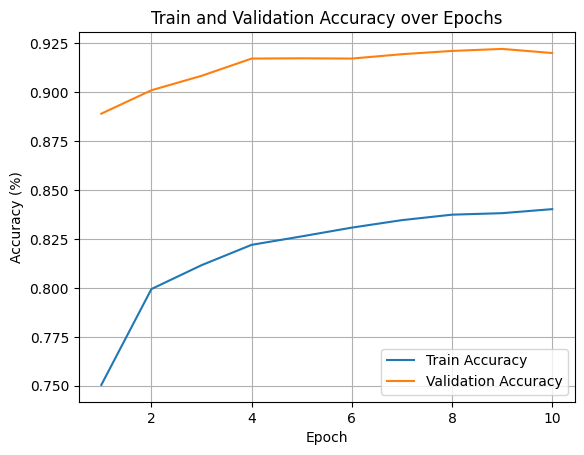

In [28]:
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()